In [1]:
# 1. Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
# 2. Load data
df = pd.read_csv("../data/telco_dataset_cleaned.csv") 
df.head()


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 3. Target encoding
df["churn_flag"] = df["churn"].map({"Yes": 1, "No": 0})
df["churn_flag"].value_counts(normalize=True)


churn_flag
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [7]:
# 4. Feature selection

# Numeric features
numeric_features = [
    "tenure",
    "monthlycharges",
    "totalcharges"
]

# Categorical features 
categorical_features = [
    "contract",
    "internetservice",
    "paymentmethod",
    "gender",
    "seniorcitizen",
    "partner",
    "dependents",
    "phoneservice",
    "multiplelines",
    "paperlessbilling"
]

# Filter to existing columns only
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

x = df[numeric_features + categorical_features]
y = df["churn_flag"]

x.shape, y.shape


((7032, 13), (7032,))

In [9]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
from sklearn.utils.class_weight import compute_class_weight

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Handle class imbalance with class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

# Model
log_reg = LogisticRegression(
    max_iter=500,
    class_weight=class_weight_dict,
    n_jobs=-1
)

# Pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

clf


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# 7. Fit the pipeline
clf.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


ROC-AUC: 0.8344174332586154

Classification report:

              precision    recall  f1-score   support

           0       0.90      0.70      0.78      1033
           1       0.48      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



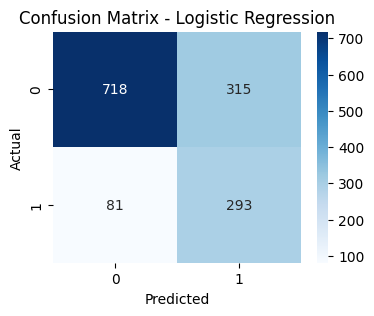

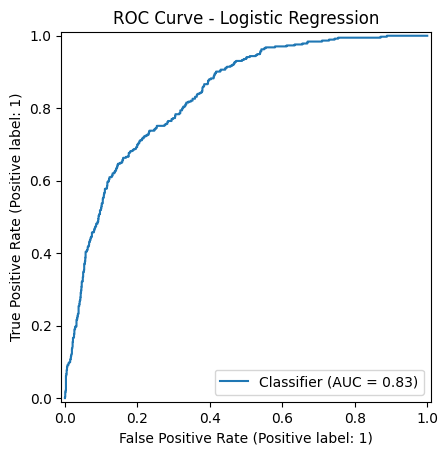

In [18]:
# 8. Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()


In [20]:
# 9. Score the full dataset
full_proba = clf.predict_proba(x)[:, 1]

df_scores = df[["customerid"]].copy()  # adjust to the correct ID column name
df_scores["churn_proba"] = full_proba

# Risk segments
df_scores["churn_risk_segment"] = pd.cut(
    df_scores["churn_proba"],
    bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

df_scores.head()


,customerid,churn_proba,churn_risk_segment
0,7590-VHVEG,0.829445,Very High
1,5575-GNVDE,0.129918,Very Low
2,3668-QPYBK,0.611120,High
3,7795-CFOCW,0.145114,Very Low
4,9237-HQITU,0.858900,Very High


In [22]:
df_scores.to_csv("../data/churn_model_scores.csv", index=False)


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

rf_clf.fit(X_train, y_train)

y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification report (RF):\n")
print(classification_report(y_test, y_pred_rf))


Random Forest ROC-AUC: 0.8304701533874133

Classification report (RF):

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.56      0.65      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407



In [24]:
x

,tenure,monthlycharges,totalcharges,contract,internetservice,paymentmethod,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,paperlessbilling
0,1,29.85,29.85,Month-to-month,DSL,Electronic check,Female,0,Yes,No,No,No phone service,Yes
1,34,56.95,1889.50,One year,DSL,Mailed check,Male,0,No,No,Yes,No,No
2,2,53.85,108.15,Month-to-month,DSL,Mailed check,Male,0,No,No,Yes,No,Yes
3,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),Male,0,No,No,No,No phone service,No
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Female,0,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,24,84.80,1990.50,One year,DSL,Mailed check,Male,0,Yes,Yes,Yes,Yes,Yes
7028,72,103.20,7362.90,One year,Fiber optic,Credit card (automatic),Female,0,Yes,Yes,Yes,Yes,Yes
7029,11,29.60,346.45,Month-to-month,DSL,Electronic check,Female,0,Yes,Yes,No,No phone service,Yes
7030,4,74.40,306.60,Month-to-month,Fiber optic,Mailed check,Male,1,Yes,No,Yes,Yes,Yes
